## How to use this notebook

- **Single-run cells**: The first few code cells run one set of simulations for the three AI policies and are used by any Gantt or single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per policy and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [15]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
    plot_average_waiting_and_service_by_step,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 2000
RANDOM_SEED = 36

In [16]:
# Run all three simulations
print(f"Running standard simulation with {NUM_PERMITS} permits...")
# Edit these values to test additional assumptions.
SIMULATION_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "simulation_duration": None,
    "permit_mix": "all_custom_non_like_for_like",
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 1,
    "fire_caseload_per_staff": 7,
}

common_run_kwargs = {
    "num_permits": NUM_PERMITS,
    "random_seed": RANDOM_SEED,
    **SIMULATION_PARAMS,
}

sim_standard = run_simulation(
    **common_run_kwargs,
    ai_review="none",
)

print(f"\nRunning initial AI check simulation with {NUM_PERMITS} permits...")
sim_initial = run_simulation(
    **common_run_kwargs,
    ai_review="initial_check",
)

print(f"\nRunning full AI review simulation with {NUM_PERMITS} permits...")
sim_full = run_simulation(
    **common_run_kwargs,
    ai_review="full_review",
)

Running standard simulation with 2000 permits...

Running initial AI check simulation with 2000 permits...

Running full AI review simulation with 2000 permits...


In [17]:
# Print statistics for each process
print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("=== AI INITIAL CHECK PROCESS ===")
stats_initial = sim_initial.get_statistics()
print_statistics(stats_initial)

print("\n=== AI FULL REVIEW PROCESS ===")
stats_full = sim_full.get_statistics()
print_statistics(stats_full)

=== STANDARD PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 2000
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :    0 ( 0.00%)
  CUSTOM_NON_LIKE               : 2000 (100.00%)
  PRE_APPROVED_LIKE             :    0 ( 0.00%)
  PRE_APPROVED_NON_LIKE         :    0 ( 0.00%)
  SELF_CERT_LIKE                :    0 ( 0.00%)
  SELF_CERT_NON_LIKE            :    0 ( 0.00%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     978.41 days
  Median:   976.04 days
  Std Dev:  455.79 days
  Min:      120.83 days
  Max:     1875.98 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT


In [18]:
# Run multiple simulations for each AI scenario to see aggregate behavior
N_RUNS = 100

# Edit these values to test additional assumptions across all AI scenarios.
SIMULATION_DURATION = None
MULTI_RUN_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "permit_mix": "all_custom_non_like_for_like",
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 2,
    "fire_caseload_per_staff": 7,
}

scenario_params_list = [
    {"name": "Standard", **MULTI_RUN_PARAMS, "ai_review": "none"},
    {"name": "Initial AI Check", **MULTI_RUN_PARAMS, "ai_review": "initial_check"},
    {"name": "Full AI Review", **MULTI_RUN_PARAMS, "ai_review": "full_review"},
]

multi_run_kwargs = {
    "n_runs": N_RUNS,
    "num_permits": NUM_PERMITS,
    "simulation_duration": SIMULATION_DURATION,
    "base_seed": RANDOM_SEED,
    "scenario_params_list": scenario_params_list,
    "collect_permits": True,
}

multi_results = run_multiple_simulations(**multi_run_kwargs)

all_standard_permits: list = []
all_initial_permits: list = []
all_full_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Initial AI Check":
        all_initial_permits.extend(permits)
    elif scenario == "Full AI Review":
        all_full_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


from simulation_plot_helpers import permits_partitioned_by_run

runs_by_process = {
    "Standard": permits_partitioned_by_run(multi_results, "Standard"),
    "Initial AI Check": permits_partitioned_by_run(multi_results, "Initial AI Check"),
    "Full AI Review": permits_partitioned_by_run(multi_results, "Full AI Review"),
}

print(f"Ran {N_RUNS} runs per scenario (AI policies). Aggregate total-time stats:")
_print_summary("Standard", all_standard_permits)
_print_summary("Initial AI Check", all_initial_permits)
_print_summary("Full AI Review", all_full_permits)

Ran 100 runs per scenario (AI policies). Aggregate total-time stats:
Standard: n=200000, mean=968.97, median=961.83
Initial AI Check: n=200000, mean=759.84, median=753.51
Full AI Review: n=200000, mean=371.34, median=346.99


**Total time disaster → construction by segment (days)**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Standard | Custom non-like,200000,100,576.677244,961.829496,1355.686831,100.200452,2507.439368
1,Initial AI Check | Custom non-like,200000,100,475.775866,753.513076,1039.855876,93.396781,1868.532721
2,Full AI Review | Custom non-like,200000,100,278.027041,346.992073,435.891252,82.033563,672.645686


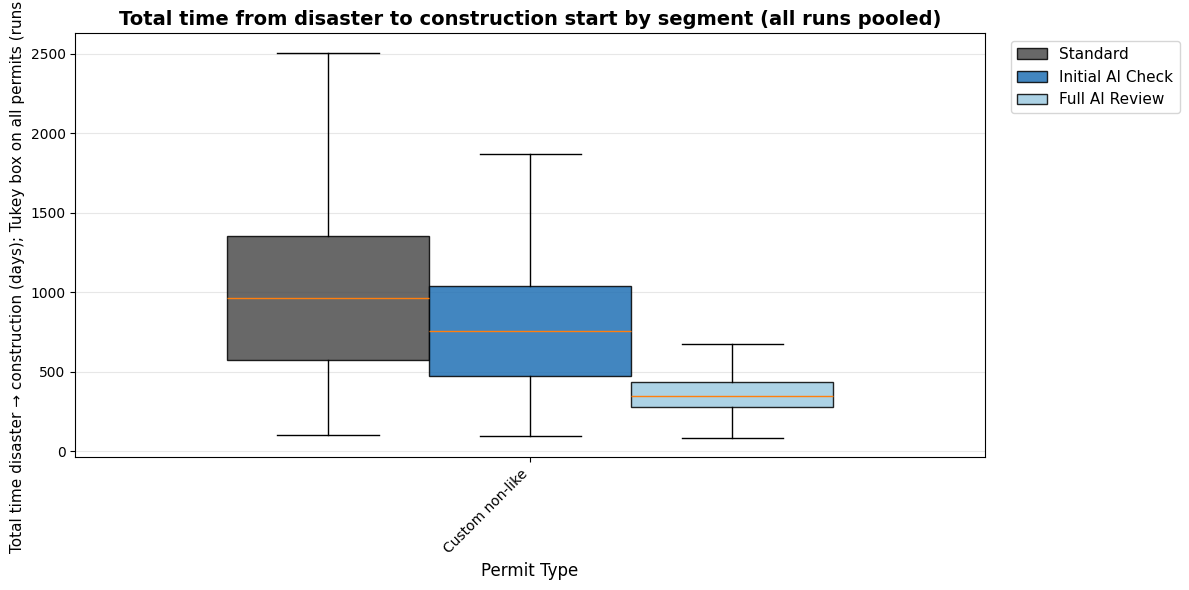

In [19]:
# Compare median total time (disaster to construction) by segment
# Within-run medians across Monte Carlo runs (see runs_by_process from prior cell)
fig, ax = plot_median_total_time_by_process(runs_by_process)
if fig is not None:
    plt.show()

In [20]:
# Diagnostic: non-like-for-like step-level timeline comparison by AI policy
import pandas as pd
from permit_simulation import Segment

NON_LIKE_SEGMENTS = {
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
}


def _non_like_step_summary(permits: list) -> dict:
    non_like = [p for p in permits if p.segment in NON_LIKE_SEGMENTS and p.ready_for_construction is not None]
    if not non_like:
        return {"n": 0}

    def _mean(values):
        vals = [v for v in values if v is not None]
        return float(np.mean(vals)) if vals else np.nan

    return {
        "n": len(non_like),
        "total_time": _mean([p.ready_for_construction - p.created_at for p in non_like]),
        "planning_wait": _mean([p.planning_total_waiting for p in non_like]),
        "planning_service": _mean([p.planning_initial_service + p.planning_recheck_service for p in non_like]),
        "public_works_wait": _mean([p.public_works_total_waiting for p in non_like]),
        "public_works_service": _mean([p.public_works_initial_service + p.public_works_recheck_service for p in non_like]),
        "fire_wait": _mean([p.fire_review_total_waiting for p in non_like]),
        "fire_service": _mean([p.fire_initial_service + p.fire_recheck_service for p in non_like]),
        "agency_referral_total": _mean([
            (p.agency_referral_end - p.agency_referral_request)
            if p.agency_referral_request is not None and p.agency_referral_end is not None
            else 0.0
            for p in non_like
        ]),
        "special_zoning_service": _mean([
            (p.zoning_end - p.zoning_start)
            if p.zoning_start is not None and p.zoning_end is not None
            else 0.0
            for p in non_like
        ]),
        "applicant_revisions": _mean([p.applicant_revisions_total_time for p in non_like]),
    }


scenario_non_like = {
    "Standard": _non_like_step_summary(all_standard_permits),
    "Initial AI Check": _non_like_step_summary(all_initial_permits),
    "Full AI Review": _non_like_step_summary(all_full_permits),
}

comparison_df = pd.DataFrame(scenario_non_like).T
comparison_df = comparison_df[[
    "n",
    "total_time",
    "planning_wait",
    "planning_service",
    "public_works_wait",
    "public_works_service",
    "fire_wait",
    "fire_service",
    "agency_referral_total",
    "special_zoning_service",
    "applicant_revisions",
]].round(2)

print("Non-like-for-like diagnostics (mean days):")
display(comparison_df)

if "Standard" in comparison_df.index:
    delta_vs_standard = (comparison_df - comparison_df.loc["Standard"]).round(2)
    print("\nDelta vs Standard (mean days):")
    display(delta_vs_standard)


Non-like-for-like diagnostics (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,200000.0,968.97,582.48,10.0,0.03,9.00,0.0,3.67,38.30,57.48,94.15
Initial AI Check,200000.0,759.84,377.75,7.3,0.02,6.59,0.0,2.77,38.37,57.57,93.99
Full AI Review,200000.0,371.34,0.01,1.0,0.00,0.90,0.0,0.37,38.28,57.52,93.91



Delta vs Standard (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00
Initial AI Check,0.0,-209.13,-204.73,-2.7,-0.01,-2.41,0.0,-0.9,0.07,0.09,-0.16
Full AI Review,0.0,-597.63,-582.47,-9.0,-0.03,-8.10,0.0,-3.3,-0.02,0.04,-0.24


**Time from application to construction start by segment**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Standard | Custom non-like,200000,100,389.486106,807.768332,1127.257033,37.506892,2194.570297
1,Initial AI Check | Custom non-like,200000,100,254.473356,593.801495,809.388086,25.872911,1622.964754
2,Full AI Review | Custom non-like,200000,100,120.557266,153.418485,194.699747,15.594512,305.902578


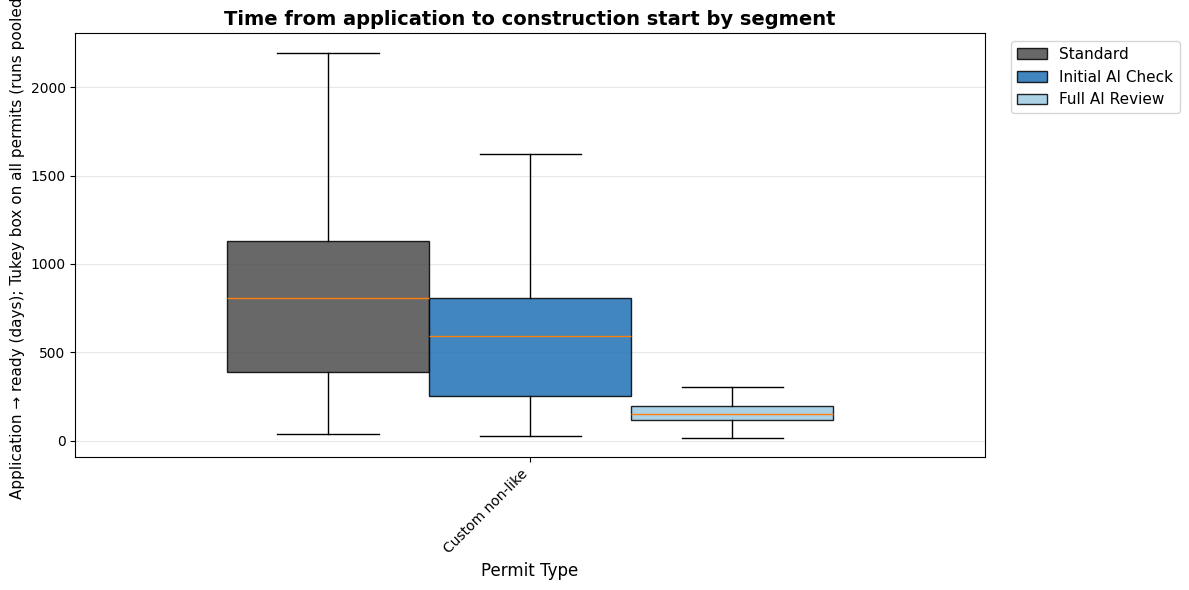

In [21]:
# Compare within-run median application-to-construction time by segment (boxplot across runs)
fig, ax = plot_median_total_time_by_process(
    runs_by_process,
    application_to_ready=True,
    title="Time from application to construction start by segment",
)
if fig is not None:
    plt.show()


In [22]:
# Simulation setup + run for segment-median AI comparisons
from permit_simulation import Segment
from simulation_plot_helpers import permits_by_scenario_partitioned_by_run

N_RUNS_PANEL = 100
BASE_SEED_PANEL = 42
PRE_APP_DIST = "lognormal_180"
PERMIT_COUNTS = [2000, 6500]
STAFFING_ORDER = ["low", "medium", "high"]
AI_SCENARIOS = [
    ("Standard", "none"),
    ("Initial AI Check", "initial_check"),
    ("Full AI Review", "full_review"),
]

STAFFING_SCENARIOS = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}

segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
segment_labels = [
    "Custom like",
    "Pre-approved like",
    "Self-certified like",
    "Custom non-like",
    "Pre-approved non-like",
    "Self-certified non-like",
]

colors = {
    "Standard": "#1976D2",
    "Initial AI Check": "#F57C00",
    "Full AI Review": "#388E3C",
}

scenario_params_list = []
for n in PERMIT_COUNTS:
    for staffing_name in STAFFING_ORDER:
        for ai_label, ai_mode in AI_SCENARIOS:
            scenario_params_list.append(
                {
                    "name": f"permits={n}|staffing={staffing_name}|ai={ai_label}",
                    "num_permits": n,
                    "pre_application_distribution": PRE_APP_DIST,
                    "sequential": "standard",
                    "ai_review": ai_mode,
                    "permit_mix": "balanced",
                    "review_duration_families": None,
                    "review_duration_multipliers": None,
                    "planning_caseload_per_staff": 7,
                    "public_works_caseload_per_staff": 7,
                    "fire_caseload_per_staff": 7,
                    **STAFFING_SCENARIOS[staffing_name],
                }
            )

results_panel = run_multiple_simulations(
    n_runs=N_RUNS_PANEL,
    base_seed=BASE_SEED_PANEL,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

runs_by_scenario = permits_by_scenario_partitioned_by_run(results_panel)

print(f"Completed {len(scenario_params_list)} scenarios × {N_RUNS_PANEL} runs each.")


Completed 18 scenarios × 100 runs each.


**AI Comparison Across Permit Types (6,500 Permits, Low Staffing)**

,series,n,n_runs,q1,median,q3,whisker_low,whisker_high
0,Standard | Custom like,260397,100,1170.358946,1987.537910,2653.867092,6.477748,3341.625698
1,Initial AI Check | Custom like,260397,100,854.568219,1463.901588,1943.778137,6.377792,2493.501754
2,Full AI Review | Custom like,260397,100,90.923613,125.208007,160.937835,0.599010,265.928233
3,Standard | Pre-approved like,129285,100,547.686145,936.451071,1508.520823,2.847666,2949.534935
4,Initial AI Check | Pre-approved like,129285,100,406.632729,732.973568,1149.181322,3.021259,2262.928912
5,Full AI Review | Pre-approved like,129285,100,94.475720,125.849606,162.289097,0.484585,263.997348
6,Standard | Self-certified like,130578,100,1167.738277,1989.198109,2653.699037,4.993787,3311.395906
7,Initial AI Check | Self-certified like,130578,100,845.556199,1462.618832,1940.968922,4.058039,2494.869851
8,Full AI Review | Self-certified like,130578,100,90.383816,124.310975,160.197645,0.331442,264.910432
9,Standard | Custom non-like,64691,100,1249.259186,2056.005992,2723.437934,51.723924,3645.264851


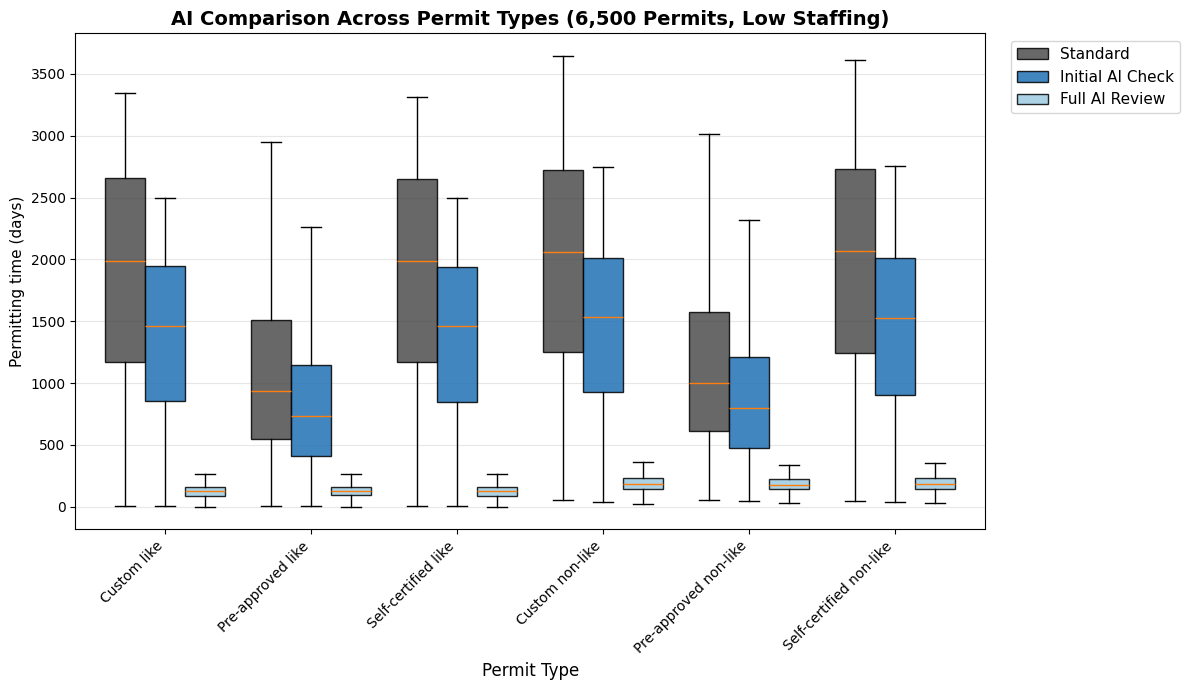

In [27]:
# Plot one selected panel at a time
SELECTED_PERMITS = 6500          # choose: 2000 or 6500
SELECTED_STAFFING = "low"         # choose: "low", "medium", "high"

if SELECTED_PERMITS not in PERMIT_COUNTS:
    raise ValueError(f"SELECTED_PERMITS must be one of {PERMIT_COUNTS}")
if SELECTED_STAFFING not in STAFFING_ORDER:
    raise ValueError(f"SELECTED_STAFFING must be one of {STAFFING_ORDER}")

runs_by_process = {
    ai_label: runs_by_scenario.get(
        f"permits={SELECTED_PERMITS}|staffing={SELECTED_STAFFING}|ai={ai_label}", []
    )
    for ai_label, _ in AI_SCENARIOS
}

fig, ax = plot_median_total_time_by_process(
    runs_by_process,
    application_to_ready=True,
    figsize=(12, 7),
    title=(
        f"AI Comparison Across Permit Types ({SELECTED_PERMITS:,} Permits, "
        f"{SELECTED_STAFFING.capitalize()} Staffing)"
    ),
)
if fig is not None:
    ax.set_ylabel("Permitting time (days)")
    plt.tight_layout()
    plt.show()
